# Prosjekt 2: Analyse av politisk inflytelse

In [91]:
import sys
!{sys.executable} -m pip install numpy

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [93]:
df_DS1 = pd.read_stata("DS1_v2.dta")
df_DS1.head()


,ID8102,YEAR,OUTCOME,OUTCMYEAR,switcher,instresp,XL_AREA,age1_fav,age2_fav,age3_fav,...,UnitedAutoWorkersunion,Universities,VeteransofForeignWarsoftheU_S,ECYN,SWYN,FPYN,RLYN,GNYN,Questext,_merge
0,1.0,1981.0,0.0,NaN,0.0,1.0,budget,84.0,91.0,116.0,...,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,Now let me ask you about a number of specific ...,matched (3)
1,2.0,1981.0,0.0,NaN,0.0,1.0,taxation,71.0,91.0,103.0,...,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,In addition to the tax cuts the President call...,matched (3)
2,3.0,1981.0,2.0,NaN,0.0,1.0,welf reform,62.0,82.0,94.0,...,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,Now let me ask you about a number of specific ...,matched (3)
3,4.0,1981.0,2.0,NaN,0.0,1.0,taxation,82.0,101.0,109.0,...,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,In addition to the tax cuts the President call...,matched (3)
4,5.0,1981.0,4.0,1984.0,0.0,1.0,misc others,59.0,69.0,77.0,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,Now let me ask you about a number of specific ...,matched (3)


In [94]:
df_DS1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1863 entries, 0 to 1862
Columns: 265 entries, ID8102 to _merge
dtypes: category(1), float64(262), str(2)
memory usage: 3.8 MB


In [95]:
print(*df_DS1.columns, sep='\n')

ID8102
YEAR
OUTCOME
OUTCMYEAR
switcher
instresp
XL_AREA
age1_fav
age2_fav
age3_fav
age4_fav
age5_fav
age6_fav
age7_fav
age8_fav
age9_fav
age10_fav
age11_fav
age12_fav
age1_opp
age2_opp
age3_opp
age4_opp
age5_opp
age6_opp
age7_opp
age8_opp
age9_opp
age10_opp
age11_opp
age12_opp
age1_dk
age2_dk
age3_dk
age4_dk
age5_dk
age6_dk
age7_dk
age8_dk
age9_dk
age10_dk
age11_dk
age12_dk
edu1_fav
edu2_fav
edu3_fav
edu4_fav
edu5_fav
edu6_fav
edu7_fav
edu8_fav
edu9_fav
edu10_fav
edu11_fav
edu12_fav
edu1_opp
edu2_opp
edu3_opp
edu4_opp
edu5_opp
edu6_opp
edu7_opp
edu8_opp
edu9_opp
edu10_opp
edu11_opp
edu12_opp
edu1_dk
edu2_dk
edu3_dk
edu4_dk
edu5_dk
edu6_dk
edu7_dk
edu8_dk
edu9_dk
edu10_dk
edu11_dk
edu12_dk
inc1_fav
inc2_fav
inc3_fav
inc4_fav
inc5_fav
inc6_fav
inc7_fav
inc8_fav
inc9_fav
inc10_fav
inc11_fav
inc12_fav
inc1_opp
inc2_opp
inc3_opp
inc4_opp
inc5_opp
inc6_opp
inc7_opp
inc8_opp
inc9_opp
inc10_opp
inc11_opp
inc12_opp
inc1_dk
inc2_dk
inc3_dk
inc4_dk
inc5_dk
inc6_dk
inc7_dk
inc8_dk
inc9_dk
inc10_dk

In [96]:
print(df_DS1['Questext'][3])

In addition to the tax cuts the President called for in his speech before Congress, President Reagan and his economic advisors are working on another tax cut program designed to stimulate investment to make the economy grow. Would you favor or oppose (READ EACH ITEM)? Item: Reducing the maximum tax rate that individuals pay on income other than their salaries from 70% to 50%                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [97]:
print(df_DS1["XL_AREA"].unique())

<StringArray>
[      'budget',     'taxation',  'welf reform',  'misc others',
      'defense',  'foreign pol',    'education',       'health',
  'soc welfare',  'environment',  'govt reform', 'econ & labor',
 'camp finance',         'race',    'religious',         'guns',
    'civil rts',    'terrorism',  'immigration']
Length: 19, dtype: str


Informasjon om variabler her: https://www.russellsage.org/sites/default/files/datasets/gilens_RepresentationalInequalityVariableDescriptions.pdf 

In [98]:
interesting_columns = ['OUTCOME', 'INSTRESP', 'XL_AREA'  ]

In [99]:
print(df_DS1[['pred10_sw', 'pred30_sw', 'pred50_sw', 'pred70_sw', 'pred90_sw', 'PREDALL_SW']].isna().sum())

pred10_sw     27
pred30_sw     27
pred50_sw     27
pred70_sw     27
pred90_sw     27
PREDALL_SW    27
dtype: int64


# 1. Enkel regresjonsanalyse

Trening av en logistisk modell som skal predikere outcome gitt andelen i forskjellige inntektsgruppers preferanser. Sammenlikner koeffisienter på tvers av områder. 

In [100]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
def get_all_group_coefficients(df, category_column, feature_cols):
    all_results = []

    groups = list(df[category_column].unique()) + ['ALL_GROUPS']
    
    for group in groups:
        if group == 'ALL_GROUPS':
            group_df = df
        else:
            group_df = df[df[category_column] == group]

        clean_df = group_df[['OUTCOME'] + feature_cols].dropna()
            
        Y = (clean_df['OUTCOME'] != 0).astype(int)
        X = clean_df[feature_cols]
        
        model = LogisticRegression()
        model.fit(X, Y)
        
        group_results = {'Category': group}
        for col, coef in zip(feature_cols, model.coef_[0]):
            group_results[col] = coef
            
        all_results.append(group_results)

    coef_df = pd.DataFrame(all_results).set_index('Category')

    plt.figure(figsize=(12, 10))

    sns.heatmap(coef_df, annot=True, cmap="RdBu_r", center=0, fmt=".3f", linewidths=0.5)

    plt.title('Logistic Regression Coefficients across Income Groups', fontsize=16)
    plt.ylabel('Income Categories', fontsize=12)
    plt.xlabel('Features', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

    return coef_df



In [102]:
all_cols = ['pred10_sw', 'pred30_sw', 'pred50_sw', 'pred70_sw', 'pred90_sw', 'PREDALL_SW']
only_poor = ['pred10_sw']
general = ['PREDALL_SW']



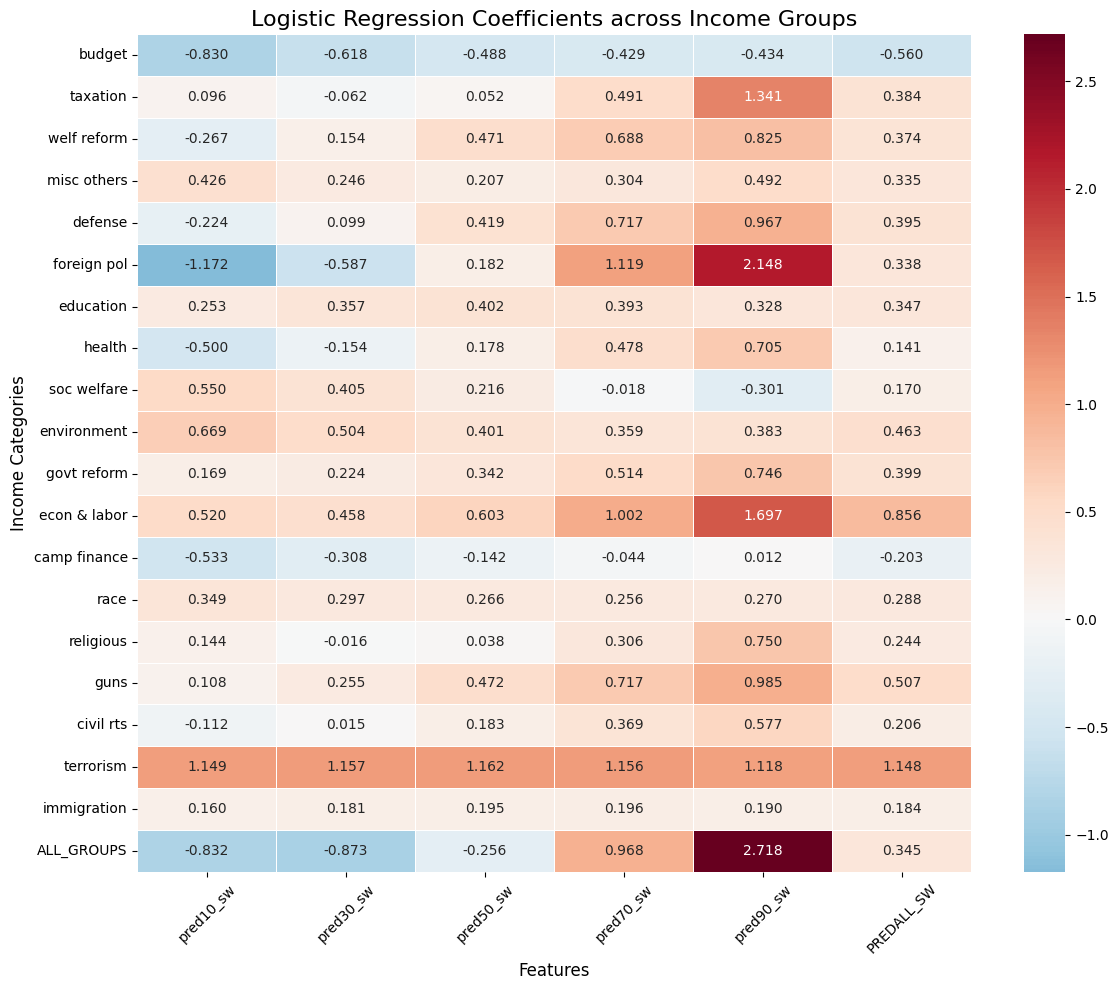

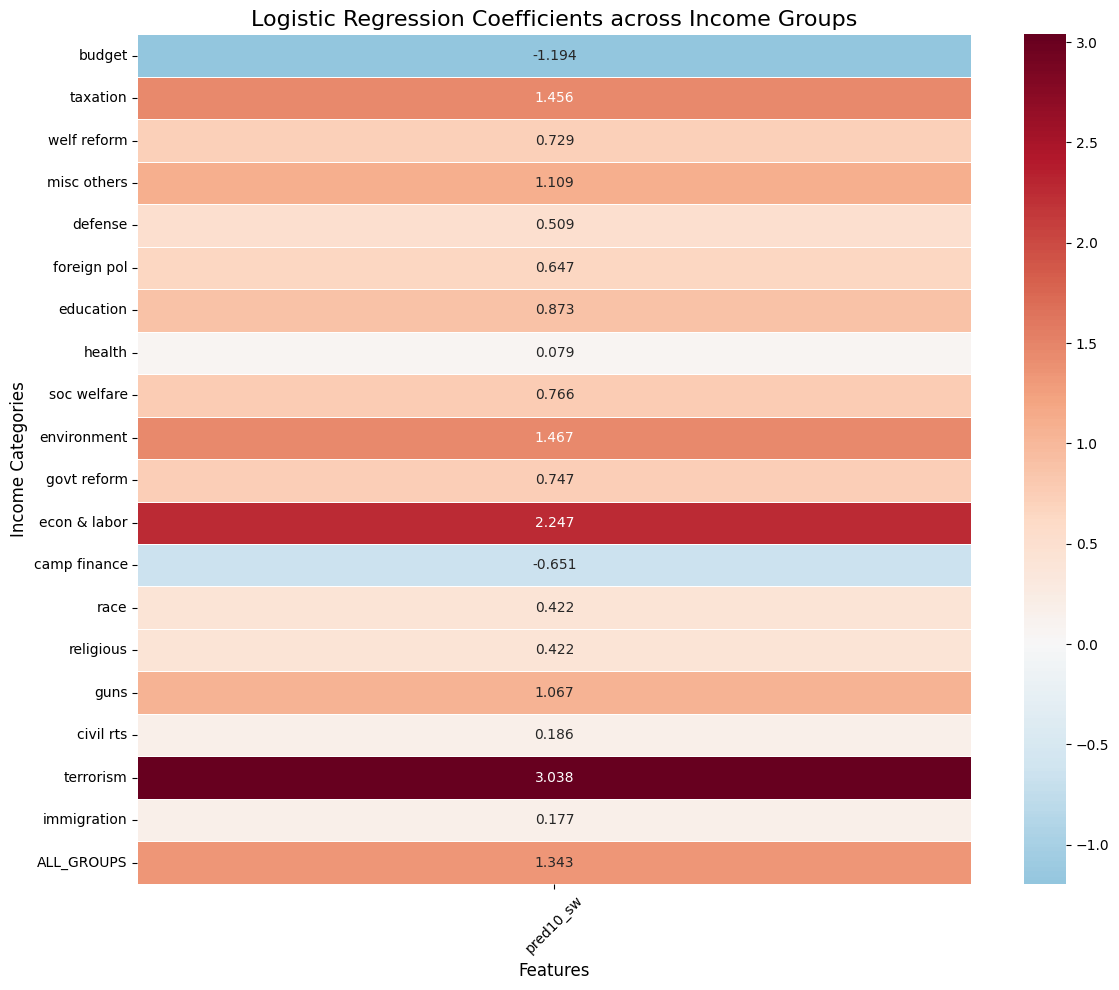

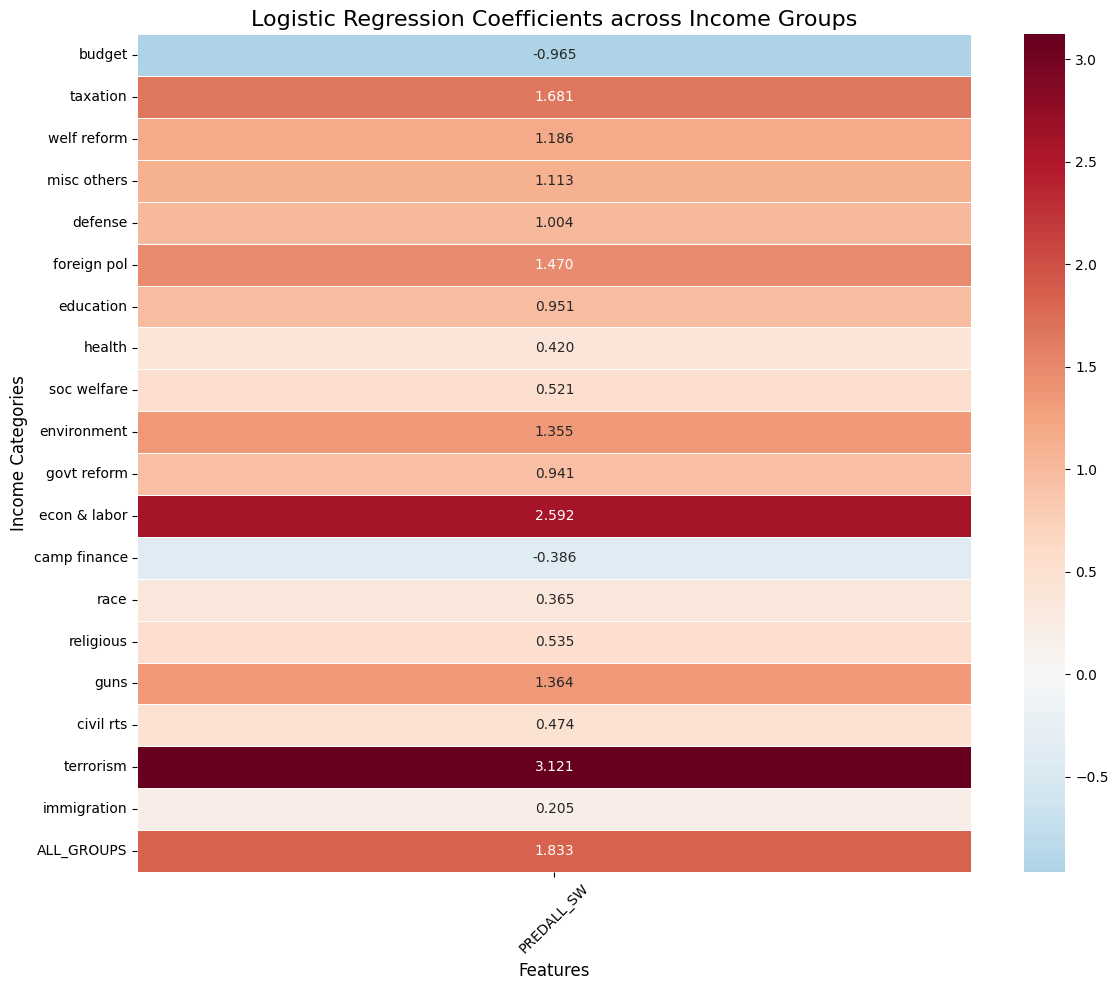

In [103]:
df_coefs_all = get_all_group_coefficients(df_DS1, 'XL_AREA', all_cols)
df_coefs_poor = get_all_group_coefficients(df_DS1, 'XL_AREA', only_poor)
df_coefs_general = get_all_group_coefficients(df_DS1, 'XL_AREA', general)


